In [1]:
# ============================================================
# A.E.D.A.S. — Exploration des datasets
# Notebook 01 : UrbanSound8K + ESC-50
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path

# Chemins de base
BASE_DIR    = Path("..") 
US8K_META   = BASE_DIR / "data/raw/urbansound8k/UrbanSound8K.csv"
US8K_AUDIO  = BASE_DIR / "data/raw/urbansound8k"
ESC50_META  = BASE_DIR / "data/raw/esc50/meta/esc50.csv"
ESC50_AUDIO = BASE_DIR / "data/raw/esc50/audio"

print("Librairies chargées ✓")
print(f"librosa version : {librosa.__version__}")

Librairies chargées ✓
librosa version : 0.11.0


In [2]:
# ============================================================
# Cellule 2 : Exploration du CSV UrbanSound8K
# ============================================================

df = pd.read_csv(US8K_META)

print(f"Total fichiers : {len(df)}")
print(f"Classes disponibles :\n{df.groupby(['classID','class']).size().to_string()}")
print(f"\nNombre de sirènes : {len(df[df['class'] == 'siren'])}")
print(f"Distribution sirènes par fold :")
print(df[df['class'] == 'siren'].groupby('fold').size().to_string())
print(f"\nDistribution salience (1=foreground, 2=background) :")
print(df[df['class'] == 'siren'].groupby('salience').size().to_string())

Total fichiers : 8732
Classes disponibles :
classID  class           
0        air_conditioner     1000
1        car_horn             429
2        children_playing    1000
3        dog_bark            1000
4        drilling            1000
5        engine_idling       1000
6        gun_shot             374
7        jackhammer          1000
8        siren                929
9        street_music        1000

Nombre de sirènes : 929
Distribution sirènes par fold :
fold
1      86
2      91
3     119
4     166
5      71
6      74
7      77
8      80
9      82
10     83

Distribution salience (1=foreground, 2=background) :
salience
1    269
2    660


Fichier sélectionné : 102871-8-0-0.wav
Fold : 2 | Salience : 1
Durée originale : 4.00s
Durée chargée : 4.00s | Sample rate : 22050 Hz | Samples : 88200


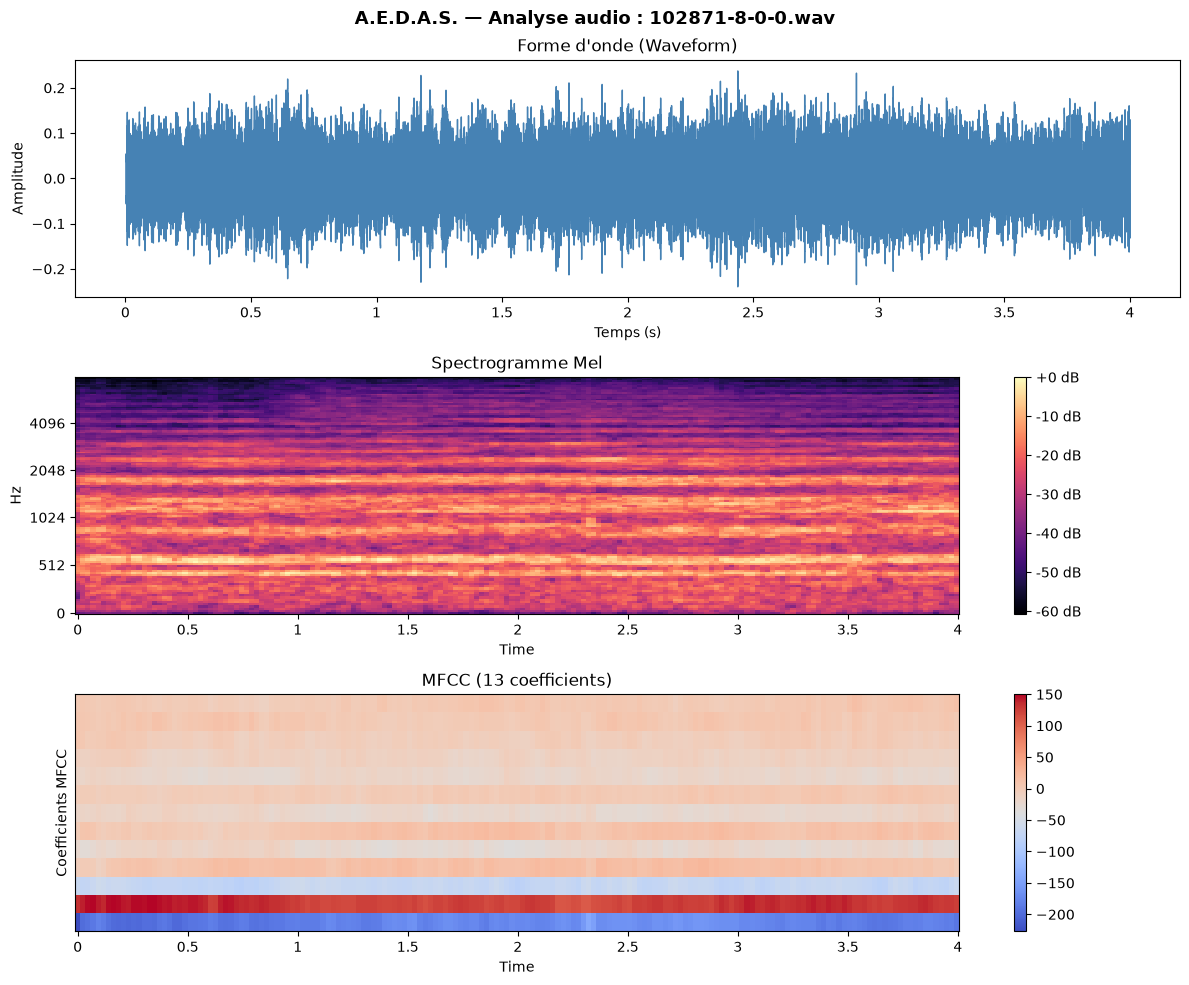

Figure sauvegardée dans reports/ ✓


In [3]:
# ============================================================
# Cellule 3 : Visualisation d'un fichier siren (UrbanSound8K)
# ============================================================

# Sélectionner un fichier siren foreground (salience=1) pour une visualisation claire
siren_files = df[(df['class'] == 'siren') & (df['salience'] == 1)]
sample = siren_files.iloc[0]

# Construire le chemin complet
audio_path = US8K_AUDIO / f"fold{sample['fold']}" / sample['slice_file_name']
print(f"Fichier sélectionné : {sample['slice_file_name']}")
print(f"Fold : {sample['fold']} | Salience : {sample['salience']}")
print(f"Durée originale : {sample['end'] - sample['start']:.2f}s")

# Charger avec librosa
y, sr = librosa.load(audio_path, sr=22050)
duration = librosa.get_duration(y=y, sr=sr)
print(f"Durée chargée : {duration:.2f}s | Sample rate : {sr} Hz | Samples : {len(y)}")

# ---- Figure avec 3 visualisations ----
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle(f"A.E.D.A.S. — Analyse audio : {sample['slice_file_name']}", 
             fontsize=13, fontweight='bold')

# 1. Forme d'onde
ax1 = axes[0]
librosa.display.waveshow(y, sr=sr, ax=ax1, color='steelblue')
ax1.set_title("Forme d'onde (Waveform)")
ax1.set_xlabel("Temps (s)")
ax1.set_ylabel("Amplitude")

# 2. Spectrogramme mel
ax2 = axes[1]
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', 
                                y_axis='mel', fmax=8000, ax=ax2, cmap='magma')
fig.colorbar(img, ax=ax2, format='%+2.0f dB')
ax2.set_title("Spectrogramme Mel")

# 3. MFCC (13 coefficients — base de notre feature vector)
ax3 = axes[2]
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
img2 = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=ax3, cmap='coolwarm')
fig.colorbar(img2, ax=ax3)
ax3.set_title("MFCC (13 coefficients)")
ax3.set_ylabel("Coefficients MFCC")

plt.tight_layout()
plt.savefig("../reports/exploration_siren_sample.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée dans reports/ ✓")

In [4]:
# ============================================================
# Cellule 4 : Exploration du CSV ESC-50
# ============================================================

df_esc = pd.read_csv(ESC50_META)

print(f"Total fichiers ESC-50 : {len(df_esc)}")
print(f"Colonnes disponibles : {list(df_esc.columns)}")
print(f"\nDistribution des classes utilisées pour A.E.D.A.S. :")

classes_utiles = ['siren', 'car_horn', 'engine', 'rain', 'wind', 'street_music']
mask = df_esc['category'].isin(classes_utiles)
print(df_esc[mask].groupby('category').size().to_string())

print(f"\nTotal fichiers utiles (positifs + négatifs) : {mask.sum()}")
print(f"\nAperçu du CSV :")
print(df_esc[mask][['filename', 'fold', 'target', 'category']].head(10).to_string())

Total fichiers ESC-50 : 2000
Colonnes disponibles : ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take']

Distribution des classes utilisées pour A.E.D.A.S. :
category
car_horn    40
engine      40
rain        40
siren       40
wind        40

Total fichiers utiles (positifs + négatifs) : 200

Aperçu du CSV :
              filename  fold  target  category
37   1-137296-A-16.wav     1      16      wind
53    1-17124-A-43.wav     1      43  car_horn
62    1-17367-A-10.wav     1      10      rain
74    1-18527-A-44.wav     1      44    engine
75    1-18527-B-44.wav     1      44    engine
83    1-19026-A-43.wav     1      43  car_horn
107   1-21189-A-10.wav     1      10      rain
116   1-22882-A-44.wav     1      44    engine
124   1-24074-A-43.wav     1      43  car_horn
125   1-24076-A-43.wav     1      43  car_horn


Fichier ESC-50 sélectionné : 1-31482-A-42.wav
Fold : 1

UrbanSound8K — durée : 4.00s
ESC-50        — durée : 5.00s


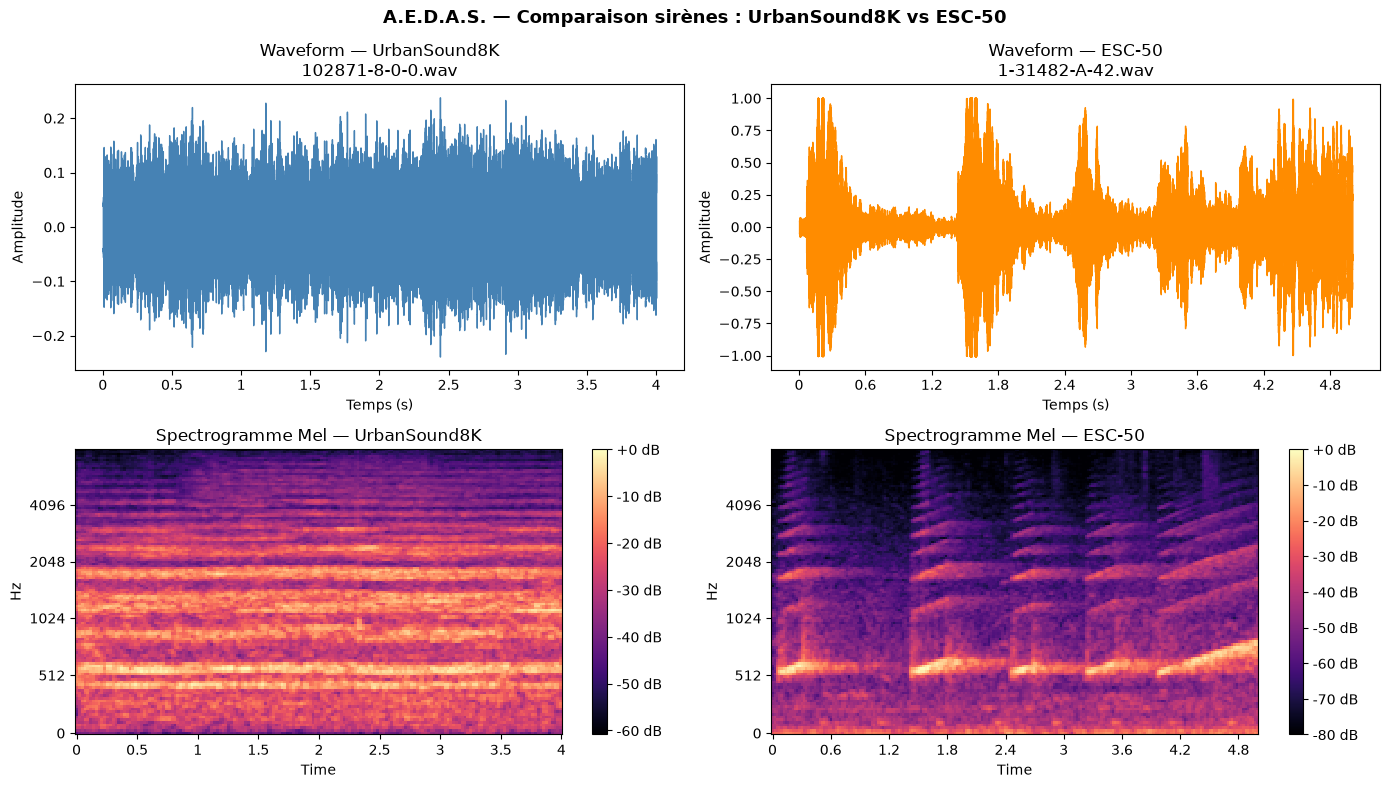

Figure comparative sauvegardée dans reports/ ✓


In [5]:
# ============================================================
# Cellule 5 : Visualisation siren ESC-50 + comparaison
# ============================================================

# Sélectionner un fichier siren ESC-50
siren_esc = df_esc[df_esc['category'] == 'siren'].iloc[0]
audio_path_esc = ESC50_AUDIO / siren_esc['filename']

print(f"Fichier ESC-50 sélectionné : {siren_esc['filename']}")
print(f"Fold : {siren_esc['fold']}")

# Charger les deux fichiers pour comparaison
y_us8k, sr_us8k = librosa.load(
    US8K_AUDIO / f"fold{sample['fold']}" / sample['slice_file_name'], 
    sr=22050
)
y_esc, sr_esc = librosa.load(audio_path_esc, sr=22050)

print(f"\nUrbanSound8K — durée : {librosa.get_duration(y=y_us8k, sr=sr_us8k):.2f}s")
print(f"ESC-50        — durée : {librosa.get_duration(y=y_esc, sr=sr_esc):.2f}s")

# ---- Figure comparative ----
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("A.E.D.A.S. — Comparaison sirènes : UrbanSound8K vs ESC-50",
             fontsize=13, fontweight='bold')

# UrbanSound8K — waveform
librosa.display.waveshow(y_us8k, sr=sr_us8k, ax=axes[0,0], color='steelblue')
axes[0,0].set_title(f"Waveform — UrbanSound8K\n{sample['slice_file_name']}")
axes[0,0].set_xlabel("Temps (s)")
axes[0,0].set_ylabel("Amplitude")

# ESC-50 — waveform
librosa.display.waveshow(y_esc, sr=sr_esc, ax=axes[0,1], color='darkorange')
axes[0,1].set_title(f"Waveform — ESC-50\n{siren_esc['filename']}")
axes[0,1].set_xlabel("Temps (s)")
axes[0,1].set_ylabel("Amplitude")

# UrbanSound8K — Mel spectrogram
mel_us8k = librosa.power_to_db(
    librosa.feature.melspectrogram(y=y_us8k, sr=sr_us8k, n_mels=128, fmax=8000),
    ref=np.max
)
img1 = librosa.display.specshow(mel_us8k, sr=sr_us8k, x_axis='time',
                                 y_axis='mel', fmax=8000, ax=axes[1,0], cmap='magma')
fig.colorbar(img1, ax=axes[1,0], format='%+2.0f dB')
axes[1,0].set_title("Spectrogramme Mel — UrbanSound8K")

# ESC-50 — Mel spectrogram
mel_esc = librosa.power_to_db(
    librosa.feature.melspectrogram(y=y_esc, sr=sr_esc, n_mels=128, fmax=8000),
    ref=np.max
)
img2 = librosa.display.specshow(mel_esc, sr=sr_esc, x_axis='time',
                                 y_axis='mel', fmax=8000, ax=axes[1,1], cmap='magma')
fig.colorbar(img2, ax=axes[1,1], format='%+2.0f dB')
axes[1,1].set_title("Spectrogramme Mel — ESC-50")

plt.tight_layout()
plt.savefig("../reports/comparaison_sirenes_US8K_ESC50.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure comparative sauvegardée dans reports/ ✓")

   A.E.D.A.S. — Résumé du dataset d'entraînement

📁 UrbanSound8K
   Total fichiers     : 8732
   Sirènes (positifs) : 929
   Autres  (négatifs) : 7803
   Durée moyenne      : 3.61s
   Sample rate        : variable (original Freesound)
   Folds              : 10 (validation croisée obligatoire)

📁 ESC-50
   Total fichiers utiles : 200
   Sirènes (positifs)    : 40
   Négatifs (4 classes)  : 160
   Durée fixe            : 5.0s par fichier
   Sample rate           : 44100 Hz (resamplé à 22050 en chargement)

   BILAN COMBINÉ
   Total positifs (siren)  : 969
   Total négatifs          : 7963
   Total fichiers          : 8932
   Ratio positifs/total    : 10.8%


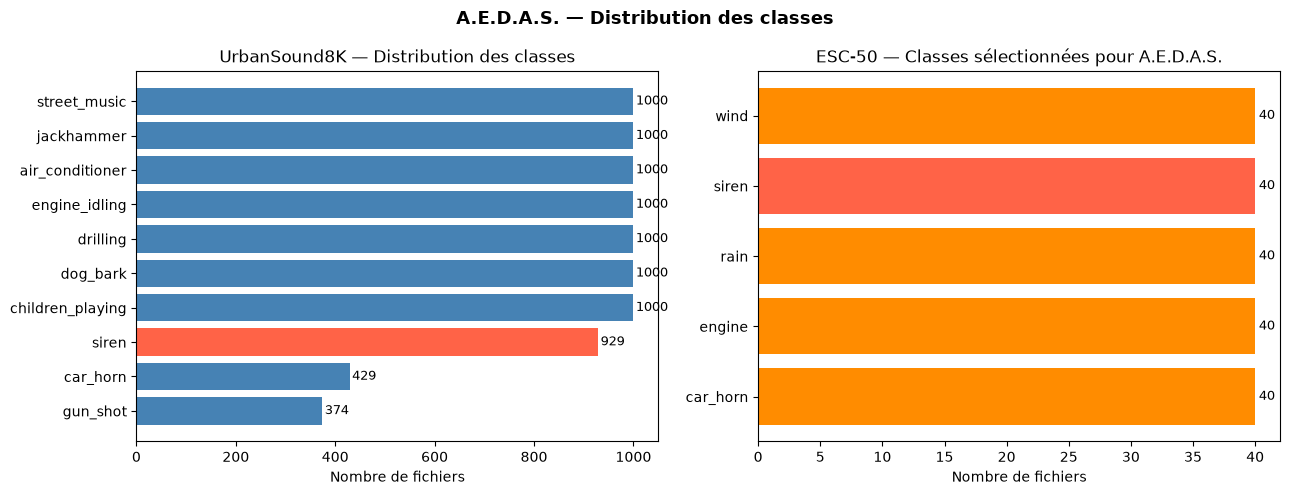

Figure distribution sauvegardée dans reports/ ✓

✅ Exploration terminée — dataset prêt pour la phase de prétraitement.


In [6]:
# ============================================================
# Cellule 6 : Résumé statistique global — dataset A.E.D.A.S.
# ============================================================

print("=" * 55)
print("   A.E.D.A.S. — Résumé du dataset d'entraînement")
print("=" * 55)

# --- UrbanSound8K ---
us8k_siren   = df[df['class'] == 'siren']
us8k_neg     = df[df['class'] != 'siren']

print(f"\n📁 UrbanSound8K")
print(f"   Total fichiers     : {len(df)}")
print(f"   Sirènes (positifs) : {len(us8k_siren)}")
print(f"   Autres  (négatifs) : {len(us8k_neg)}")
print(f"   Durée moyenne      : {(df['end'] - df['start']).mean():.2f}s")
print(f"   Sample rate        : variable (original Freesound)")
print(f"   Folds              : 10 (validation croisée obligatoire)")

# --- ESC-50 ---
esc_siren    = df_esc[df_esc['category'] == 'siren']
esc_neg      = df_esc[df_esc['category'].isin(['car_horn','engine','rain','wind'])]

print(f"\n📁 ESC-50")
print(f"   Total fichiers utiles : {len(esc_siren) + len(esc_neg)}")
print(f"   Sirènes (positifs)    : {len(esc_siren)}")
print(f"   Négatifs (4 classes)  : {len(esc_neg)}")
print(f"   Durée fixe            : 5.0s par fichier")
print(f"   Sample rate           : 44100 Hz (resamplé à 22050 en chargement)")

# --- Bilan combiné ---
total_pos = len(us8k_siren) + len(esc_siren)
total_neg = len(us8k_neg)   + len(esc_neg)
total     = total_pos + total_neg

print(f"\n{'=' * 55}")
print(f"   BILAN COMBINÉ")
print(f"{'=' * 55}")
print(f"   Total positifs (siren)  : {total_pos}")
print(f"   Total négatifs          : {total_neg}")
print(f"   Total fichiers          : {total}")
print(f"   Ratio positifs/total    : {total_pos/total*100:.1f}%")

# --- Visualisation distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("A.E.D.A.S. — Distribution des classes", 
             fontsize=13, fontweight='bold')

# UrbanSound8K — toutes classes
counts_us8k = df.groupby('class').size().sort_values(ascending=True)
axes[0].barh(counts_us8k.index, counts_us8k.values, 
             color=['tomato' if c == 'siren' else 'steelblue' 
                    for c in counts_us8k.index])
axes[0].set_title("UrbanSound8K — Distribution des classes")
axes[0].set_xlabel("Nombre de fichiers")
for i, v in enumerate(counts_us8k.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# ESC-50 — classes utiles seulement
counts_esc = df_esc[df_esc['category'].isin(
    ['siren','car_horn','engine','rain','wind'])
].groupby('category').size().sort_values(ascending=True)
axes[1].barh(counts_esc.index, counts_esc.values,
             color=['tomato' if c == 'siren' else 'darkorange' 
                    for c in counts_esc.index])
axes[1].set_title("ESC-50 — Classes sélectionnées pour A.E.D.A.S.")
axes[1].set_xlabel("Nombre de fichiers")
for i, v in enumerate(counts_esc.values):
    axes[1].text(v + 0.3, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig("../reports/distribution_classes_AEDAS.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure distribution sauvegardée dans reports/ ✓")
print("\n✅ Exploration terminée — dataset prêt pour la phase de prétraitement.")